# Aula 05 - Exercício Prático: Word Embeddings

**Curso:** Processamento de Linguagem Natural  
**Aluno:** Gisele Fonseca
**Data:** 26 de janeiro de 2026
## Instruções
1. Complete todos os exercícios marcados com `# === SEU CÓDIGO AQUI ===`
2. Execute as células de teste para verificar suas respostas
3. **Não modifique as células de teste**
4. Execute todas as células em ordem
5. Respostas devem ser armazenadas nas variáveis indicadas

## Critérios de Avaliação
- **Conteúdo (100%):** Testes automáticos

---

## Dataset

Utilizaremos o dataset **B2W-Reviews01** para treinar modelos de embeddings.

---

---

## Setup do Ambiente

Execute as células abaixo para configurar o ambiente de correção.

In [1]:
# === CONFIGURAÇÃO INICIAL ===

!pip install --upgrade pip --quiet
!pip cache purge
!pip install otter-grader --no-cache-dir -q
!pip install gensim nltk scikit-learn --quiet
!mkdir -p tests

print("Ambiente configurado!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.7 MB/s eta 0:00:00
Files removed: 6 (1.8 MB)
Ambiente configurado!


In [2]:
# Criar diretório de testes
import os
os.makedirs('tests', exist_ok=True)

In [3]:
%%writefile tests/q1.py
OK_FORMAT = True
test = {
    "name": "q1",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> 'modelo_word2vec_q1' in dir()
True
"""
                },
                {
                    "code": r"""
>>> from gensim.models import Word2Vec
>>> isinstance(modelo_word2vec_q1, Word2Vec)
True
"""
                },
                {
                    "code": r"""
>>> modelo_word2vec_q1.wv.vector_size == 150
True
"""
                },
                {
                    "code": r"""
>>> modelo_word2vec_q1.window == 4
True
"""
                },
                {
                    "code": r"""
>>> modelo_word2vec_q1.min_count == 3
True
"""
                },
                {
                    "code": r"""
>>> modelo_word2vec_q1.sg == 1
True
"""
                },
                {
                    "code": r"""
>>> len(modelo_word2vec_q1.wv) > 100
True
"""
                },
                {
                    "code": r"""
>>> 'produto' in modelo_word2vec_q1.wv
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q1.py


In [4]:
%%writefile tests/q2.py
OK_FORMAT = True
test = {
    "name": "q2",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> 'palavras_similares_bom' in dir()
True
"""
                },
                {
                    "code": r"""
>>> 'palavras_similares_ruim' in dir()
True
"""
                },
                {
                    "code": r"""
>>> isinstance(palavras_similares_bom, list)
True
"""
                },
                {
                    "code": r"""
>>> len(palavras_similares_bom) == 8
True
"""
                },
                {
                    "code": r"""
>>> len(palavras_similares_ruim) == 8
True
"""
                },
                {
                    "code": r"""
>>> all(isinstance(item, tuple) and len(item) == 2 for item in palavras_similares_bom)
True
"""
                },
                {
                    "code": r"""
>>> all(isinstance(p, str) and isinstance(s, float) for p, s in palavras_similares_bom)
True
"""
                },
                {
                    "code": r"""
>>> scores_bom = [s for p, s in palavras_similares_bom]
>>> scores_bom == sorted(scores_bom, reverse=True)
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q2.py


In [5]:
%%writefile tests/q3.py
OK_FORMAT = True
test = {
    "name": "q3",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> callable(calcular_similaridade_palavras)
True
"""
                },
                {
                    "code": r"""
>>> result = calcular_similaridade_palavras('produto', 'celular', modelo_word2vec_q1)
>>> isinstance(result, float)
True
"""
                },
                {
                    "code": r"""
>>> result = calcular_similaridade_palavras('produto', 'celular', modelo_word2vec_q1)
>>> -1.0 <= result <= 1.0
True
"""
                },
                {
                    "code": r"""
>>> result_mesmo = calcular_similaridade_palavras('produto', 'produto', modelo_word2vec_q1)
>>> 0.99 <= result_mesmo <= 1.01
True
"""
                },
                {
                    "code": r"""
>>> result_oov = calcular_similaridade_palavras('xyz123nonexistent', 'produto', modelo_word2vec_q1)
>>> result_oov is None
True
"""
                },
                {
                    "code": r"""
>>> 'similaridade_bom_otimo' in dir()
True
"""
                },
                {
                    "code": r"""
>>> 'similaridade_bom_ruim' in dir()
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q3.py


In [6]:
%%writefile tests/q4.py
OK_FORMAT = True
test = {
    "name": "q4",
    "points": 14,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> callable(criar_embedding_documento)
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> result = criar_embedding_documento("produto bom", modelo_word2vec_q1)
>>> isinstance(result, np.ndarray)
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> result = criar_embedding_documento("produto bom", modelo_word2vec_q1)
>>> result.shape == (150,)
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> result = criar_embedding_documento("", modelo_word2vec_q1)
>>> np.allclose(result, np.zeros(150))
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> result = criar_embedding_documento("xyz123 abc456", modelo_word2vec_q1)
>>> np.allclose(result, np.zeros(150))
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> result = criar_embedding_documento("produto", modelo_word2vec_q1)
>>> vetor_direto = modelo_word2vec_q1.wv['produto']
>>> np.allclose(result, vetor_direto)
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q4.py


In [7]:
%%writefile tests/q5.py
OK_FORMAT = True
test = {
    "name": "q5",
    "points": 14,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> callable(buscar_documentos_semantica)
True
"""
                },
                {
                    "code": r"""
>>> docs_teste = ["produto bom", "entrega rápida", "muito ruim"]
>>> result = buscar_documentos_semantica("ótimo", docs_teste, modelo_word2vec_q1, top_n=2)
>>> isinstance(result, list)
True
"""
                },
                {
                    "code": r"""
>>> docs_teste = ["produto bom", "entrega rápida", "muito ruim"]
>>> result = buscar_documentos_semantica("ótimo", docs_teste, modelo_word2vec_q1, top_n=2)
>>> len(result) == 2
True
"""
                },
                {
                    "code": r"""
>>> docs_teste = ["produto bom", "entrega rápida", "muito ruim"]
>>> result = buscar_documentos_semantica("ótimo", docs_teste, modelo_word2vec_q1, top_n=2)
>>> all(isinstance(item, tuple) and len(item) == 2 for item in result)
True
"""
                },
                {
                    "code": r"""
>>> docs_teste = ["produto bom", "entrega rápida", "muito ruim"]
>>> result = buscar_documentos_semantica("ótimo", docs_teste, modelo_word2vec_q1, top_n=2)
>>> all(isinstance(doc, str) and isinstance(score, float) for doc, score in result)
True
"""
                },
                {
                    "code": r"""
>>> docs_teste = ["produto bom", "entrega rápida", "muito ruim"]
>>> result = buscar_documentos_semantica("ótimo", docs_teste, modelo_word2vec_q1, top_n=2)
>>> scores = [s for d, s in result]
>>> scores == sorted(scores, reverse=True)
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q5.py


In [8]:
%%writefile tests/q6.py
OK_FORMAT = True
test = {
    "name": "q6",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> 'modelo_fasttext_q6' in dir()
True
"""
                },
                {
                    "code": r"""
>>> from gensim.models import FastText
>>> isinstance(modelo_fasttext_q6, FastText)
True
"""
                },
                {
                    "code": r"""
>>> modelo_fasttext_q6.wv.vector_size == 100
True
"""
                },
                {
                    "code": r"""
>>> modelo_fasttext_q6.wv.min_n == 3
True
"""
                },
                {
                    "code": r"""
>>> modelo_fasttext_q6.wv.max_n == 6
True
"""
                },
                {
                    "code": r"""
>>> 'vetor_oov_produtinho' in dir()
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> isinstance(vetor_oov_produtinho, np.ndarray)
True
"""
                },
                {
                    "code": r"""
>>> vetor_oov_produtinho.shape == (100,)
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> not np.allclose(vetor_oov_produtinho, np.zeros(100))
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q6.py


In [9]:
%%writefile tests/q7.py
OK_FORMAT = True
test = {
    "name": "q7",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> 'matriz_embeddings_q7' in dir()
True
"""
                },
                {
                    "code": r"""
>>> 'similaridade_emb_q7' in dir()
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> isinstance(matriz_embeddings_q7, np.ndarray)
True
"""
                },
                {
                    "code": r"""
>>> matriz_embeddings_q7.shape == (4, 150)
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> isinstance(similaridade_emb_q7, np.ndarray)
True
"""
                },
                {
                    "code": r"""
>>> similaridade_emb_q7.shape == (4, 4)
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> np.allclose(np.diag(similaridade_emb_q7), 1.0, atol=0.01)
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> np.allclose(similaridade_emb_q7, similaridade_emb_q7.T, atol=0.01)
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q7.py


In [10]:
%%writefile tests/q8.py
OK_FORMAT = True
test = {
    "name": "q8",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> callable(realizar_analogia)
True
"""
                },
                {
                    "code": r"""
>>> result = realizar_analogia('bom', 'produto', 'entrega', modelo_word2vec_q1, topn=5)
>>> isinstance(result, list) or result is None
True
"""
                },
                {
                    "code": r"""
>>> result = realizar_analogia('bom', 'produto', 'entrega', modelo_word2vec_q1, topn=5)
>>> result is None or len(result) == 5
True
"""
                },
                {
                    "code": r"""
>>> result = realizar_analogia('bom', 'produto', 'entrega', modelo_word2vec_q1, topn=5)
>>> result is None or all(isinstance(item, tuple) and len(item) == 2 for item in result)
True
"""
                },
                {
                    "code": r"""
>>> result = realizar_analogia('xyz_nao_existe', 'produto', 'entrega', modelo_word2vec_q1, topn=5)
>>> result is None
True
"""
                },
                {
                    "code": r"""
>>> 'resultado_analogia_q8' in dir()
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q8.py


---

## Imports e Configuração

In [11]:
# @title
# Imports e configurações
import otter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import random

from gensim.models import Word2Vec, FastText
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

# Configurações
import warnings
warnings.filterwarnings('ignore')

# Seed para reprodutibilidade
random.seed(42)
np.random.seed(42)

# Inicializar grader
grader = otter.Notebook()

print("Setup completo!")

Setup completo!


---

## Carregamento dos Dados

In [12]:
# Carregar dataset B2W-Reviews (NÃO MODIFIQUE)
URL_DATASET = "https://raw.githubusercontent.com/americanas-tech/b2w-reviews01/main/B2W-Reviews01.csv"

df = pd.read_csv(URL_DATASET, nrows=8000)
df = df.dropna(subset=['review_text'])

print(f"Dataset carregado: {len(df)} reviews")

Dataset carregado: 7759 reviews


In [13]:
# Função de pré-processamento (NÃO MODIFIQUE)
def preprocessar_texto_embeddings(texto):
    """
    Pré-processa texto para embeddings.
    Retorna lista de tokens.
    """
    if not isinstance(texto, str):
        return []
    texto = texto.lower()
    texto = re.sub(r'[^a-záàâãéèêíïóôõöúçñ\s]', ' ', texto)
    tokens = texto.split()
    tokens = [t for t in tokens if len(t) > 1]
    return tokens

# Preparar corpus tokenizado (NÃO MODIFIQUE)
CORPUS_TOKENIZADO = df['review_text'].apply(preprocessar_texto_embeddings).tolist()
CORPUS_TOKENIZADO = [sent for sent in CORPUS_TOKENIZADO if len(sent) > 0]

print(f"Corpus preparado: {len(CORPUS_TOKENIZADO)} sentenças")
print(f"Exemplo: {CORPUS_TOKENIZADO[0][:10]}...")

Corpus preparado: 7755 sentenças
Exemplo: ['estou', 'contente', 'com', 'compra', 'entrega', 'rápida', 'único', 'problema', 'com', 'as']...


---

## Questão 1: Treinando Word2Vec

Treine um modelo Word2Vec com as seguintes configurações **exatas**:

| Parâmetro | Valor |
|-----------|-------|
| vector_size | 150 |
| window | 4 |
| min_count | 3 |
| sg | 1 (Skip-gram) |
| negative | 5 |
| epochs | 10 |
| seed | 42 |
| workers | 1 |

**Você deve criar:**
- `modelo_word2vec_q1`: Modelo Word2Vec treinado no `CORPUS_TOKENIZADO`

In [14]:
# === SEU CÓDIGO AQUI ===
modelo_word2vec_q1 = Word2Vec(
    sentences=CORPUS_TOKENIZADO,
    vector_size=150,
    window=4,
    min_count=3,
    sg=1,
    negative=5,
    epochs=10,
    seed=42,
    workers=1
)

In [15]:
# Visualizar resultado
print(f"Modelo treinado!")
print(f"  Vocabulário: {len(modelo_word2vec_q1.wv)} palavras")
print(f"  Dimensão: {modelo_word2vec_q1.wv.vector_size}")
print(f"  Window: {modelo_word2vec_q1.window}")
print(f"  Min count: {modelo_word2vec_q1.min_count}")
print(f"  Skip-gram: {modelo_word2vec_q1.sg == 1}")

Modelo treinado!
  Vocabulário: 3726 palavras
  Dimensão: 150
  Window: 4
  Min count: 3
  Skip-gram: True


In [16]:
grader.check("q1")

q1 results: All test cases passed!

---

## Questão 2: Encontrando Palavras Similares

Use o modelo treinado na Q1 para encontrar palavras similares.

**Você deve criar:**
1. `palavras_similares_bom`: Lista de **8** palavras mais similares a **'bom'**
2. `palavras_similares_ruim`: Lista de **8** palavras mais similares a **'ruim'**

**Formato de cada lista:** Lista de tuplas `[(palavra, score), ...]`

**Dica:** Use `modelo_word2vec_q1.wv.most_similar()`

In [17]:
# === SEU CÓDIGO AQUI ===
palavras_similares_bom = modelo_word2vec_q1.wv.most_similar('bom', topn=8)
palavras_similares_ruim = modelo_word2vec_q1.wv.most_similar('ruim', topn=8)

In [18]:
# Visualizar resultado
print("Palavras similares a 'bom':")
for palavra, score in palavras_similares_bom:
    print(f"  {palavra}: {score:.3f}")

print("\nPalavras similares a 'ruim':")
for palavra, score in palavras_similares_ruim:
    print(f"  {palavra}: {score:.3f}")

Palavras similares a 'bom':
  tenis: 0.757
  geral: 0.745
  extrema: 0.742
  confere: 0.740
  equipamento: 0.739
  otimo: 0.734
  belo: 0.733
  bonito: 0.732

Palavras similares a 'ruim':
  estranho: 0.760
  única: 0.736
  coisa: 0.733
  unica: 0.731
  so: 0.723
  senti: 0.720
  vagabundo: 0.708
  ilustrativa: 0.706


In [19]:
grader.check("q2")

q2 results: All test cases passed!

---

## Questão 3: Calculando Similaridade entre Palavras

Implemente uma função que calcula a similaridade entre duas palavras.

**Você deve criar:**
1. `calcular_similaridade_palavras(palavra1, palavra2, modelo)`: Função que retorna similaridade
2. `similaridade_bom_otimo`: Similaridade entre 'bom' e 'ótimo' (ou 'otimo')
3. `similaridade_bom_ruim`: Similaridade entre 'bom' e 'ruim'

**Requisitos da função:**
- Se alguma palavra não estiver no vocabulário, retornar `None`
- Usar `modelo.wv.similarity()` internamente

In [29]:
def calcular_similaridade_palavras(palavra1, palavra2, modelo):
    """
    Calcula similaridade do cosseno entre duas palavras.

    Parâmetros:
        palavra1: primeira palavra
        palavra2: segunda palavra
        modelo: modelo Word2Vec treinado

    Retorna:
        float: similaridade entre -1 e 1, ou None se palavra não existe
    """
    # === SEU CÓDIGO AQUI ===
    if palavra1 not in modelo.wv or palavra2 not in modelo.wv:
        return None

    return float(modelo.wv.similarity(palavra1, palavra2))

similaridade_bom_otimo = calcular_similaridade_palavras('bom', 'ótimo', modelo_word2vec_q1)
similaridade_bom_ruim = calcular_similaridade_palavras('bom', 'ruim', modelo_word2vec_q1)


In [30]:
# Visualizar resultado
print(f"Similaridade 'bom' - 'ótimo': {similaridade_bom_otimo}")
print(f"Similaridade 'bom' - 'ruim': {similaridade_bom_ruim}")

# Teste com palavra inexistente
teste_oov = calcular_similaridade_palavras('xyz123', 'bom', modelo_word2vec_q1)
print(f"Teste OOV (deve ser None): {teste_oov}")

Similaridade 'bom' - 'ótimo': 0.6235445141792297
Similaridade 'bom' - 'ruim': 0.432971715927124
Teste OOV (deve ser None): None


In [31]:
grader.check("q3")

q3 results: All test cases passed!

---

## Questão 4: Document Embedding

Implemente uma função que cria um embedding para um documento inteiro usando a **média dos embeddings das palavras**.

**Você deve criar:**
- `criar_embedding_documento(texto, modelo)`: Função que retorna vetor numpy

**Requisitos:**
- Usar a função `preprocessar_texto_embeddings` (já definida) para tokenizar
- Retornar a média dos vetores das palavras que estão no modelo
- Se nenhuma palavra estiver no vocabulário, retornar vetor de zeros com dimensão correta
- Retornar array numpy com shape `(vector_size,)`

In [24]:
def criar_embedding_documento(texto, modelo):
    """
    Cria embedding de documento usando média dos word embeddings.

    Parâmetros:
        texto: string com o documento
        modelo: modelo Word2Vec treinado

    Retorna:
        numpy array: vetor do documento com shape (vector_size,)
    """
# === SEU CÓDIGO AQUI ===
    tokens = preprocessar_texto_embeddings(texto)
    vetores = [modelo.wv[t] for t in tokens if t in modelo.wv]

    if len(vetores) == 0:
        return np.zeros(modelo.wv.vector_size)

    return np.mean(vetores, axis=0)

In [25]:
# Visualizar resultado
doc_teste = "Produto excelente, muito bom!"
vetor_doc = criar_embedding_documento(doc_teste, modelo_word2vec_q1)

print(f"Documento: '{doc_teste}'")
print(f"Embedding shape: {vetor_doc.shape}")
print(f"Primeiros 5 valores: {vetor_doc[:5].round(3)}")

# Teste com texto vazio
vetor_vazio = criar_embedding_documento("", modelo_word2vec_q1)
print(f"\nTexto vazio - shape: {vetor_vazio.shape}, soma: {vetor_vazio.sum()}")

Documento: 'Produto excelente, muito bom!'
Embedding shape: (150,)
Primeiros 5 valores: [ 0.32  -0.104  0.002 -0.033  0.065]

Texto vazio - shape: (150,), soma: 0.0


In [26]:
grader.check("q4")

q4 results: All test cases passed!

---

## Questão 5: Busca Semântica

Implemente uma função de busca semântica usando embeddings.

**Você deve criar:**
- `buscar_documentos_semantica(query, documentos, modelo, top_n)`: Função de busca

**Requisitos:**
- Converter query e todos os documentos para embeddings (use `criar_embedding_documento`)
- Calcular similaridade do cosseno entre query e cada documento
- Retornar lista de tuplas `[(documento, similaridade), ...]` ordenada por similaridade decrescente
- Retornar apenas os `top_n` documentos mais relevantes

In [40]:
def buscar_documentos_semantica(query, documentos, modelo, top_n=5):
    """
    Busca documentos semanticamente similares à query.

    Parâmetros:
        query: string de busca
        documentos: lista de strings (documentos)
        modelo: modelo Word2Vec treinado
        top_n: número de resultados a retornar

    Retorna:
        list: lista de tuplas (documento, similaridade) ordenada por similaridade
    """
    # === SEU CÓDIGO AQUI ===
    emb_query = criar_embedding_documento(query, modelo).reshape(1, -1)

    resultados = []
    for doc in documentos:
        emb_doc = criar_embedding_documento(doc, modelo).reshape(1, -1)
        sim = cosine_similarity(emb_query, emb_doc)[0][0]
        resultados.append((doc, float(sim)))

    resultados = sorted(resultados, key=lambda x: x[1], reverse=True)
    return resultados[:top_n]


In [41]:
# Visualizar resultado
docs_teste = [
    "Produto excelente, adorei!",
    "Entrega muito demorada",
    "Qualidade boa, recomendo",
    "Péssimo, veio quebrado"
]

resultados = buscar_documentos_semantica("produto bom", docs_teste, modelo_word2vec_q1, top_n=3)

print("Query: 'produto bom'")
print("\nResultados:")
for doc, score in resultados:
    print(f"  [{score:.3f}] {doc}")

Query: 'produto bom'

Resultados:
  [0.838] Produto excelente, adorei!
  [0.762] Entrega muito demorada
  [0.718] Qualidade boa, recomendo


In [42]:
grader.check("q5")

q5 results: All test cases passed!

---

## Questão 6: FastText e Palavras OOV

Treine um modelo FastText e demonstre sua capacidade de lidar com palavras fora do vocabulário (OOV).

**Você deve criar:**
1. `modelo_fasttext_q6`: Modelo FastText com as configurações:
   - `vector_size=100`
   - `window=5`
   - `min_count=3`
   - `sg=1`
   - `min_n=3`
   - `max_n=6`
   - `epochs=10`
   - `seed=42`
   - `workers=1`

2. `vetor_oov_produtinho`: Embedding da palavra **'produtinho'** (que provavelmente não está no vocabulário)

**Importante:** FastText consegue gerar embeddings para palavras OOV usando subpalavras!

In [33]:
# === SEU CÓDIGO AQUI ===
modelo_fasttext_q6 = FastText(
    sentences=CORPUS_TOKENIZADO,
    vector_size=100,
    window=5,
    min_count=3,
    sg=1,
    min_n=3,
    max_n=6,
    epochs=10,
    seed=42,
    workers=1
)

vetor_oov_produtinho = modelo_fasttext_q6.wv['produtinho']


In [34]:
# Visualizar resultado
print(f"FastText treinado!")
print(f"  Vocabulário: {len(modelo_fasttext_q6.wv)} palavras")
print(f"  min_n: {modelo_fasttext_q6.wv.min_n}")
print(f"  max_n: {modelo_fasttext_q6.wv.max_n}")

print(f"\n'produtinho' no vocabulário: {'produtinho' in modelo_fasttext_q6.wv.key_to_index}")
print(f"Vetor gerado mesmo assim: {vetor_oov_produtinho.shape}")
print(f"Primeiros 5 valores: {vetor_oov_produtinho[:5].round(3)}")

# Comparar com Word2Vec
print(f"\n'produtinho' no Word2Vec: {'produtinho' in modelo_word2vec_q1.wv}")




FastText treinado!
  Vocabulário: 3726 palavras
  min_n: 3
  max_n: 6

'produtinho' no vocabulário: False
Vetor gerado mesmo assim: (100,)
Primeiros 5 valores: [0.218 0.316 0.433 0.477 0.094]

'produtinho' no Word2Vec: False


In [35]:
grader.check("q6")

q6 results: All test cases passed!

---

## Questão 7: Matriz de Similaridade entre Documentos

Crie uma matriz de similaridade entre os documentos abaixo usando embeddings.

```python
documentos_q7 = [
    "O produto é muito bom e de qualidade",
    "Excelente produto, ótima qualidade",
    "Produto ruim, péssima qualidade",
    "A entrega foi muito rápida"
]
```

**Você deve criar:**
1. `matriz_embeddings_q7`: Array numpy de shape `(4, 150)` com os embeddings dos 4 documentos
2. `similaridade_emb_q7`: Matriz de similaridade do cosseno de shape `(4, 4)`

**Dicas:**
- Use `criar_embedding_documento` para cada documento
- Use `cosine_similarity` do sklearn para calcular a matriz

In [36]:
# Documentos para esta questão (NÃO MODIFIQUE)
documentos_q7 = [
    "O produto é muito bom e de qualidade",
    "Excelente produto, ótima qualidade",
    "Produto ruim, péssima qualidade",
    "A entrega foi muito rápida"
]

# === SEU CÓDIGO AQUI ===
matriz_embeddings_q7 = np.array([
    criar_embedding_documento(doc, modelo_word2vec_q1)
    for doc in documentos_q7
])

similaridade_emb_q7 = cosine_similarity(matriz_embeddings_q7)


In [37]:
# Visualizar resultado
print(f"Matriz de embeddings: {matriz_embeddings_q7.shape}")
print(f"Matriz de similaridade: {similaridade_emb_q7.shape}")

print("\nMatriz de Similaridade:")
df_sim = pd.DataFrame(
    similaridade_emb_q7,
    columns=[f'Doc {i+1}' for i in range(4)],
    index=[f'Doc {i+1}' for i in range(4)]
)
print(df_sim.round(3))

print("\nInterpretação:")
print(f"  Doc1 (bom) vs Doc2 (excelente): {similaridade_emb_q7[0,1]:.3f}")
print(f"  Doc1 (bom) vs Doc3 (ruim): {similaridade_emb_q7[0,2]:.3f}")

Matriz de embeddings: (4, 150)
Matriz de similaridade: (4, 4)

Matriz de Similaridade:
       Doc 1  Doc 2  Doc 3  Doc 4
Doc 1  1.000  0.885  0.858  0.785
Doc 2  0.885  1.000  0.860  0.752
Doc 3  0.858  0.860  1.000  0.703
Doc 4  0.785  0.752  0.703  1.000

Interpretação:
  Doc1 (bom) vs Doc2 (excelente): 0.885
  Doc1 (bom) vs Doc3 (ruim): 0.858


In [38]:
grader.check("q7")

q7 results: All test cases passed!

---

## Questão 8: Analogias Vetoriais

Implemente uma função para realizar analogias vetoriais.

**Você deve criar:**
1. `realizar_analogia(positivo1, negativo, positivo2, modelo, topn)`: Função que calcula `positivo1 - negativo + positivo2 ≈ ?`
2. `resultado_analogia_q8`: Resultado da analogia `'bom' - 'produto' + 'entrega'`

**Requisitos da função:**
- Se alguma palavra não estiver no vocabulário, retornar `None`
- Usar `modelo.wv.most_similar(positive=[...], negative=[...])` internamente
- Retornar lista de tuplas `[(palavra, score), ...]`

In [45]:
def realizar_analogia(positivo1, negativo, positivo2, modelo, topn=5):
    """
    Realiza analogia vetorial: positivo1 - negativo + positivo2 ≈ ?

    Exemplo: 'rei' - 'homem' + 'mulher' ≈ 'rainha'

    Parâmetros:
        positivo1: primeira palavra positiva
        negativo: palavra negativa (a ser subtraída)
        positivo2: segunda palavra positiva
        modelo: modelo Word2Vec treinado
        topn: número de resultados a retornar

    Retorna:
        list: lista de tuplas (palavra, score), ou None se alguma palavra não existe
    """
    # === SEU CÓDIGO AQUI ===
    if positivo1 not in modelo.wv or negativo not in modelo.wv or positivo2 not in modelo.wv:
        return None

    return modelo.wv.most_similar(
        positive=[positivo1, positivo2],
        negative=[negativo],
        topn=topn
    )

resultado_analogia_q8 = realizar_analogia('bom', 'produto', 'entrega', modelo_word2vec_q1, topn=5)



In [46]:
# Visualizar resultado
print("Analogia: 'bom' - 'produto' + 'entrega' ≈ ?")
print("(esperamos adjetivos positivos relacionados a entrega)")
print()
if resultado_analogia_q8:
    for palavra, score in resultado_analogia_q8:
        print(f"  {palavra}: {score:.3f}")
else:
    print("  Alguma palavra não está no vocabulário")

Analogia: 'bom' - 'produto' + 'entrega' ≈ ?
(esperamos adjetivos positivos relacionados a entrega)

  ótimo: 0.594
  exelente: 0.582
  bonito: 0.571
  definido: 0.567
  otimo: 0.566


In [47]:
grader.check("q8")

q8 results: All test cases passed!

---

## Visualização Extra (não avaliada)

Execute a célula abaixo para visualizar a matriz de similaridade:

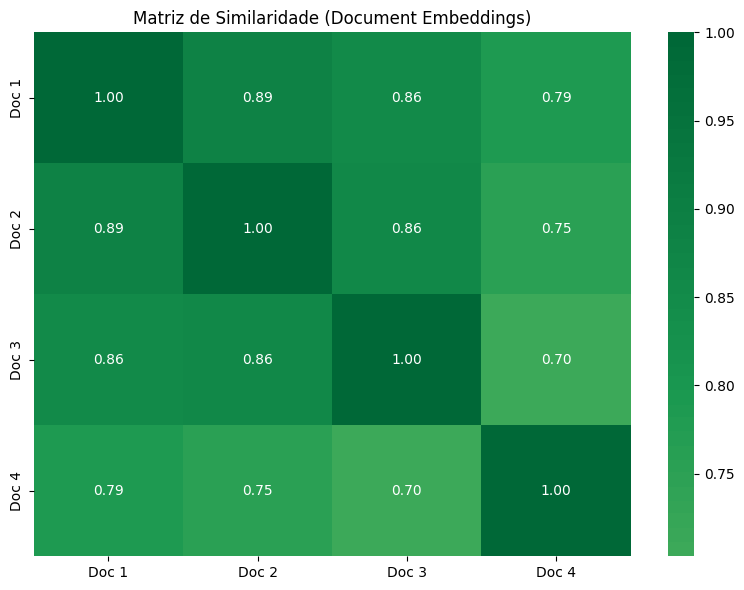


Documentos:
  Doc 1: 'O produto é muito bom e de qualidade'
  Doc 2: 'Excelente produto, ótima qualidade'
  Doc 3: 'Produto ruim, péssima qualidade'
  Doc 4: 'A entrega foi muito rápida'


In [48]:
# Visualização da matriz de similaridade
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    similaridade_emb_q7,
    annot=True,
    fmt='.2f',
    xticklabels=[f'Doc {i+1}' for i in range(4)],
    yticklabels=[f'Doc {i+1}' for i in range(4)],
    cmap='RdYlGn',
    center=0,
    ax=ax
)

ax.set_title('Matriz de Similaridade (Document Embeddings)')
plt.tight_layout()
plt.show()

print("\nDocumentos:")
for i, doc in enumerate(documentos_q7):
    print(f"  Doc {i+1}: '{doc}'")

---

## Verificação Final

Execute a célula abaixo para ver sua pontuação total:

In [49]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q6 results: All test cases passed!

q7 results: All test cases passed!

q8 results: All test cases passed!

---

**Certifique-se de que todos os testes passaram antes de submeter.**